# Wake Word Detection Model - "رشدي"

**Complete pipeline for training a DCNN-based wake word detection model**

Features:
- GPU-accelerated training (CUDA)
- Advanced audio augmentation
- Mel-spectrogram feature extraction
- Deep CNN architecture optimized for 1-second clips
- Real-time inference ready

## 1. Import Libraries

In [ ]:
import os
import sys
import random
import warnings
from pathlib import Path

import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\Elmohandes\gpu_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!
PyTorch version: 2.10.0+cu130
CUDA available: True
GPU: NVIDIA RTX A1000 Laptop GPU


## 2. Configuration

In [ ]:
# ==================== CONFIGURATION ====================

# Paths
DATA_DIR = Path("cleaned_dataset")
POSITIVE_DIR = DATA_DIR / "positive"
NEGATIVE_DIR = DATA_DIR / "negative"
MODEL_SAVE_PATH = Path("wake_word_model_best.pth")

# Audio parameters
SAMPLE_RATE = 16000
DURATION = 1.0  # seconds
N_SAMPLES = int(SAMPLE_RATE * DURATION)

# Feature extraction parameters
N_MELS = 64  # Number of mel bands
N_FFT = 1024
HOP_LENGTH = 512
FMIN = 20
FMAX = 8000

# Augmentation parameters
AUG_PROB = 0.8  # Probability of applying augmentation
TIME_SHIFT_MAX = 0.3  # Max time shift in seconds
PITCH_SHIFT_STEPS = (-3, 3)  # Pitch shift range in semitones
NOISE_FACTOR = (0.001, 0.01)  # Background noise amplitude range
SPEED_CHANGE_RANGE = (0.9, 1.1)  # Speed change range

# Training parameters
BATCH_SIZE = 32
EPOCHS = 100
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-5
PATIENCE = 15  # Early stopping patience
TRAIN_SPLIT = 0.8
VAL_SPLIT = 0.1
TEST_SPLIT = 0.1

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Configuration:")
print(f"  Device: {DEVICE}")
print(f"  Sample Rate: {SAMPLE_RATE} Hz")
print(f"  Duration: {DURATION}s")
print(f"  Mel Bands: {N_MELS}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Epochs: {EPOCHS}")

Configuration:
  Device: cuda
  Sample Rate: 16000 Hz
  Duration: 1.0s
  Mel Bands: 64
  Batch Size: 32
  Epochs: 100


## 3. Advanced Audio Augmentation Functions

These augmentations help the model generalize better and handle real-world variations.

In [ ]:
def time_shift(audio, sr, shift_max=0.3):
    """Shift audio in time by random amount."""
    shift = np.random.uniform(-shift_max, shift_max)
    shift_samples = int(shift * sr)
    
    if shift_samples > 0:
        # Shift right (delay)
        audio = np.pad(audio, (shift_samples, 0), mode='constant')[:len(audio)]
    elif shift_samples < 0:
        # Shift left (advance)
        audio = np.pad(audio, (0, -shift_samples), mode='constant')[-len(audio):]
    
    return audio


def add_background_noise(audio, noise_factor_range=(0.001, 0.01)):
    """Add random Gaussian noise to audio."""
    noise_factor = np.random.uniform(*noise_factor_range)
    noise = np.random.randn(len(audio))
    augmented = audio + noise_factor * noise
    return np.clip(augmented, -1.0, 1.0)


def pitch_shift(audio, sr, n_steps_range=(-3, 3)):
    """Shift pitch by random number of semitones."""
    n_steps = np.random.uniform(*n_steps_range)
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=n_steps)


def time_stretch(audio, rate_range=(0.9, 1.1)):
    """Change speed of audio."""
    rate = np.random.uniform(*rate_range)
    return librosa.effects.time_stretch(audio, rate=rate)


def add_env_noise(audio, noise_level_range=(0.0005, 0.005)):
    """Add colored noise (simulating environment)."""
    noise_level = np.random.uniform(*noise_level_range)
    # Generate pink noise (more natural than white noise)
    noise = np.random.randn(len(audio))
    # Simple pink noise filter
    noise = np.cumsum(noise) / (len(audio) ** 0.5)
    noise = noise - np.mean(noise)
    noise = noise / (np.max(np.abs(noise)) + 1e-8) * noise_level
    return audio + noise


def random_gain(audio, gain_range=(0.7, 1.3)):
    """Apply random gain to audio."""
    gain = np.random.uniform(*gain_range)
    return np.clip(audio * gain, -1.0, 1.0)


def spec_augment(mel_spec, freq_mask_param=8, time_mask_param=20):
    """Apply SpecAugment to mel spectrogram."""
    mel_spec = mel_spec.copy()
    n_mels, n_frames = mel_spec.shape
    
    # Frequency masking
    if np.random.rand() < 0.5:
        f_mask_width = np.random.randint(0, freq_mask_param)
        f_start = np.random.randint(0, max(1, n_mels - f_mask_width))
        mel_spec[f_start:f_start + f_mask_width, :] = mel_spec.mean()
    
    # Time masking
    if np.random.rand() < 0.5:
        t_mask_width = np.random.randint(0, min(time_mask_param, n_frames // 5))
        t_start = np.random.randint(0, max(1, n_frames - t_mask_width))
        mel_spec[:, t_start:t_start + t_mask_width] = mel_spec.mean()
    
    return mel_spec


def apply_augmentations(audio, sr, augment=True, aug_prob=0.8):
    """Apply random combination of augmentations."""
    if not augment or np.random.rand() > aug_prob:
        return audio
    
    # Randomly apply augmentations
    if np.random.rand() < 0.6:
        audio = time_shift(audio, sr, TIME_SHIFT_MAX)
    
    if np.random.rand() < 0.4:
        audio = pitch_shift(audio, sr, PITCH_SHIFT_STEPS)
    
    if np.random.rand() < 0.5:
        audio = add_background_noise(audio, NOISE_FACTOR)
    
    if np.random.rand() < 0.3:
        audio = time_stretch(audio, SPEED_CHANGE_RANGE)
        # Ensure correct length after time stretch
        if len(audio) > N_SAMPLES:
            audio = audio[:N_SAMPLES]
        elif len(audio) < N_SAMPLES:
            audio = np.pad(audio, (0, N_SAMPLES - len(audio)), mode='constant')
    
    if np.random.rand() < 0.4:
        audio = add_env_noise(audio)
    
    if np.random.rand() < 0.5:
        audio = random_gain(audio)
    
    return audio


print("Augmentation functions defined!")

Augmentation functions defined!


## 4. Feature Extraction & Preprocessing

In [ ]:
def load_and_preprocess_audio(file_path, sr=SAMPLE_RATE, duration=DURATION):
    """Load audio file and ensure it's exactly the right length."""
    try:
        audio, _ = librosa.load(file_path, sr=sr, duration=duration)
        
        # Ensure exact length
        if len(audio) > N_SAMPLES:
            audio = audio[:N_SAMPLES]
        elif len(audio) < N_SAMPLES:
            audio = np.pad(audio, (0, N_SAMPLES - len(audio)), mode='constant')
        
        # Normalize
        if np.max(np.abs(audio)) > 0:
            audio = audio / np.max(np.abs(audio))
        
        return audio
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None


def audio_to_mel_spectrogram(audio, sr=SAMPLE_RATE, n_mels=N_MELS, 
                              n_fft=N_FFT, hop_length=HOP_LENGTH,
                              fmin=FMIN, fmax=FMAX):
    """Convert audio to mel spectrogram."""
    # Compute mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        fmin=fmin,
        fmax=fmax
    )
    
    # Convert to log scale (dB)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    
    # Normalize to [0, 1]
    mel_spec_norm = (mel_spec_db - mel_spec_db.min()) / (mel_spec_db.max() - mel_spec_db.min() + 1e-8)
    
    return mel_spec_norm


def extract_features(audio, sr=SAMPLE_RATE, augment=False, apply_spec_aug=False):
    """Extract mel spectrogram features from audio."""
    # Apply audio augmentations
    if augment:
        audio = apply_augmentations(audio, sr, augment=True, aug_prob=AUG_PROB)
    
    # Convert to mel spectrogram
    mel_spec = audio_to_mel_spectrogram(audio, sr)
    
    # Apply SpecAugment
    if apply_spec_aug and augment:
        mel_spec = spec_augment(mel_spec)
    
    # Add channel dimension for CNN
    mel_spec = np.expand_dims(mel_spec, axis=0)  # Shape: (1, n_mels, n_frames)
    
    return mel_spec.astype(np.float32)


print("Feature extraction functions defined!")

Feature extraction functions defined!


## 5. Dataset Class

In [ ]:
class WakeWordDataset(Dataset):
    """Dataset for wake word detection."""
    
    def __init__(self, file_paths, labels, augment=False, cache_features=True):
        self.file_paths = file_paths
        self.labels = labels
        self.augment = augment
        self.cache_features = cache_features
        self.feature_cache = {}
        
        # Pre-load and cache if enabled
        if self.cache_features:
            print(f"Caching {'with augmentation' if augment else 'without augmentation'}...")
            for idx in tqdm(range(len(self.file_paths))):
                _ = self.__getitem__(idx)
    
    def __len__(self):
        return len(self.file_paths)
    
    def __getitem__(self, idx):
        # Check cache first (only for non-augmented data)
        if not self.augment and idx in self.feature_cache:
            return self.feature_cache[idx]
        
        file_path = self.file_paths[idx]
        label = self.labels[idx]
        
        # Load audio
        audio = load_and_preprocess_audio(file_path)
        if audio is None:
            # Return zero features if loading failed
            features = np.zeros((1, N_MELS, 32), dtype=np.float32)
        else:
            # Extract features with augmentation
            features = extract_features(
                audio,
                augment=self.augment,
                apply_spec_aug=self.augment
            )
        
        features_tensor = torch.from_numpy(features)
        label_tensor = torch.tensor(label, dtype=torch.long)
        
        # Cache if not augmenting
        if not self.augment and self.cache_features:
            self.feature_cache[idx] = (features_tensor, label_tensor)
        
        return features_tensor, label_tensor


print("Dataset class defined!")

Dataset class defined!


## 6. Load and Split Data

In [ ]:
# Load file paths
positive_files = list(POSITIVE_DIR.glob("*.wav"))
negative_files = list(NEGATIVE_DIR.glob("*.wav"))

print(f"Data Summary:")
print(f"  Positive samples: {len(positive_files)}")
print(f"  Negative samples: {len(negative_files)}")

# Create labels (1 = positive/wake word, 0 = negative)
all_files = positive_files + negative_files
all_labels = [1] * len(positive_files) + [0] * len(negative_files)

# Convert to numpy arrays
all_files = np.array(all_files)
all_labels = np.array(all_labels)

# Split: Train, Val, Test
train_files, temp_files, train_labels, temp_labels = train_test_split(
    all_files, all_labels, 
    train_size=TRAIN_SPLIT,
    stratify=all_labels,
    random_state=42
)

val_size_adjusted = VAL_SPLIT / (VAL_SPLIT + TEST_SPLIT)
val_files, test_files, val_labels, test_labels = train_test_split(
    temp_files, temp_labels,
    train_size=val_size_adjusted,
    stratify=temp_labels,
    random_state=42
)

print(f"\nSplit Summary:")
print(f"  Train: {len(train_files)} ({len(train_files[train_labels==1])} pos, {len(train_files[train_labels==0])} neg)")
print(f"  Val:   {len(val_files)} ({len(val_files[val_labels==1])} pos, {len(val_files[val_labels==0])} neg)")
print(f"  Test:  {len(test_files)} ({len(test_files[test_labels==1])} pos, {len(test_files[test_labels==0])} neg)")

Data Summary:
  Positive samples: 463
  Negative samples: 671

Split Summary:
  Train: 907 (370 pos, 537 neg)
  Val:   113 (46 pos, 67 neg)
  Test:  114 (47 pos, 67 neg)


## 7. Create Data Loaders

In [ ]:
# Create datasets
train_dataset = WakeWordDataset(train_files, train_labels, augment=True, cache_features=False)
val_dataset = WakeWordDataset(val_files, val_labels, augment=False, cache_features=True)
test_dataset = WakeWordDataset(test_files, test_labels, augment=False, cache_features=True)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,  # Set to 0 for Windows compatibility
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Data loaders created!")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")

Caching without augmentation...


100%|██████████| 113/113 [00:00<00:00, 344.96it/s]


Caching without augmentation...


100%|██████████| 114/114 [00:00<00:00, 195.59it/s]

Data loaders created!
  Train batches: 29
  Val batches: 4
  Test batches: 4


## 8. Deep CNN Model Architecture

Optimized architecture for 1-second wake word detection with residual connections.

In [ ]:
class ResidualBlock(nn.Module):
    """Residual block for better gradient flow."""
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super().__init__()
        padding = kernel_size // 2
        
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, 1, padding)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class WakeWordCNN(nn.Module):
    """Deep CNN for wake word detection optimized for 1-second clips."""
    
    def __init__(self, num_classes=2):
        super().__init__()
        
        # Initial convolution
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        
        # Residual blocks
        self.res_block1 = ResidualBlock(32, 64, stride=2)
        self.res_block2 = ResidualBlock(64, 128, stride=2)
        self.res_block3 = ResidualBlock(128, 256, stride=2)
        
        # Additional convolutional layers
        self.conv2 = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # Fully connected layers
        self.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        # Convolutional layers
        x = self.conv1(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        x = self.conv2(x)
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected
        x = self.fc(x)
        
        return x


# Initialize model
model = WakeWordCNN(num_classes=2).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model created!")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Model on device: {next(model.parameters()).device}")

Model created!
  Total parameters: 2,554,306
  Trainable parameters: 2,554,306
  Model on device: cuda:0


In [ ]:
# Calculate class weights for balanced training
class_counts = np.bincount(train_labels)
class_weights = torch.FloatTensor([len(train_labels) / (len(class_counts) * count) for count in class_counts]).to(DEVICE)

print(f"Class distribution (train):")
print(f"  Negative: {class_counts[0]} samples")
print(f"  Positive: {class_counts[1]} samples")
print(f"Class weights: {class_weights}")

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6
)

# Mixed precision scaler
scaler = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None

print(f"Training components ready!")
print(f"  Optimizer: Adam (lr={LEARNING_RATE})")
print(f"  Scheduler: ReduceLROnPlateau")
print(f"  Mixed Precision: {scaler is not None}")

Class distribution (train):
  Negative: 537 samples
  Positive: 370 samples
Class weights: tensor([0.8445, 1.2257], device='cuda:0')
Training components ready!
  Optimizer: Adam (lr=0.001)
  Scheduler: ReduceLROnPlateau
  Mixed Precision: True


## 10. Training & Validation Functions

Efficient training loop with mixed precision and metrics tracking.

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, scaler, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(dataloader, desc="Training", leave=False)
    
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        
        # Mixed precision training
        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        
        # Statistics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.0 * correct / total:.2f}%'
        })
    
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    
    return epoch_loss, epoch_acc


def validate(model, dataloader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        pbar = tqdm(dataloader, desc="Validation", leave=False)
        
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            
            # Mixed precision inference
            if device.type == 'cuda':
                with torch.cuda.amp.autocast():
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
            else:
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            
            # Statistics
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100.0 * correct / total:.2f}%'
            })
    
    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)


print("Training functions defined!")

Training functions defined!


## 11. Main Training Loop

Train with early stopping and model checkpointing.

In [ ]:
# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

# Early stopping parameters
best_val_loss = float('inf')
patience_counter = 0
EARLY_STOPPING_PATIENCE = 15
best_model_path = "kws_best.pt"

print("Starting training...")
print(f"  Epochs: {EPOCHS}")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Early stopping patience: {EARLY_STOPPING_PATIENCE}")
print()

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("-" * 60)
    
    # Train
    train_loss, train_acc = train_epoch(
        model, train_loader, criterion, optimizer, scaler, DEVICE
    )
    
    # Validate
    val_loss, val_acc, _, _ = validate(
        model, val_loader, criterion, DEVICE
    )
    
    # Update scheduler
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print epoch results
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print()
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_acc': val_acc,
            'history': history
        }, best_model_path)
        
        print(f"  Best model saved! (Val Loss: {val_loss:.4f})")
        print()
    else:
        patience_counter += 1
        print(f"  No improvement ({patience_counter}/{EARLY_STOPPING_PATIENCE})")
        print()
        
        if patience_counter >= EARLY_STOPPING_PATIENCE:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

print("Training complete!")
print(f"  Best validation loss: {best_val_loss:.4f}")
print(f"  Model saved to: {best_model_path}")

Starting training...
  Epochs: 100
  Batch size: 32
  Early stopping patience: 15

Epoch 1/100
------------------------------------------------------------


  Train Loss: 0.6977 | Train Acc: 53.14%
  Val Loss:   0.6883 | Val Acc:   52.21%

  Best model saved! (Val Loss: 0.6883)

Epoch 2/100
------------------------------------------------------------


  Train Loss: 0.6835 | Train Acc: 58.54%
  Val Loss:   0.6705 | Val Acc:   58.41%

  Best model saved! (Val Loss: 0.6705)

Epoch 3/100
------------------------------------------------------------


  Train Loss: 0.6598 | Train Acc: 60.53%
  Val Loss:   0.7360 | Val Acc:   44.25%

  No improvement (1/15)

Epoch 4/100
------------------------------------------------------------


  Train Loss: 0.6565 | Train Acc: 61.30%
  Val Loss:   0.6218 | Val Acc:   66.37%

  Best model saved! (Val Loss: 0.6218)

Epoch 5/100
------------------------------------------------------------


...

  Train Loss: 0.4496 | Train Acc: 81.15%
  Val Loss:   0.6118 | Val Acc:   70.80%

  No improvement (11/15)

Epoch 26/100
------------------------------------------------------------


  Train Loss: 0.4405 | Train Acc: 80.82%
  Val Loss:   0.6717 | Val Acc:   71.68%

  No improvement (12/15)

Epoch 27/100
------------------------------------------------------------


  Train Loss: 0.3850 | Train Acc: 84.12%
  Val Loss:   0.6610 | Val Acc:   70.80%

  No improvement (13/15)

Epoch 28/100
------------------------------------------------------------


  Train Loss: 0.3866 | Train Acc: 82.47%
  Val Loss:   0.6564 | Val Acc:   75.22%

  No improvement (14/15)

Epoch 29/100
------------------------------------------------------------


  Train Loss: 0.3487 | Train Acc: 85.45%
  Val Loss:   0.6792 | Val Acc:   69.91%

  No improvement (15/15)

Early stopping triggered after 29 epochs
Training complete!
  Best validation loss: 0.5866
  Model saved to: kws_best.pt


## 12. Plot Training History

Visualize loss and accuracy curves.

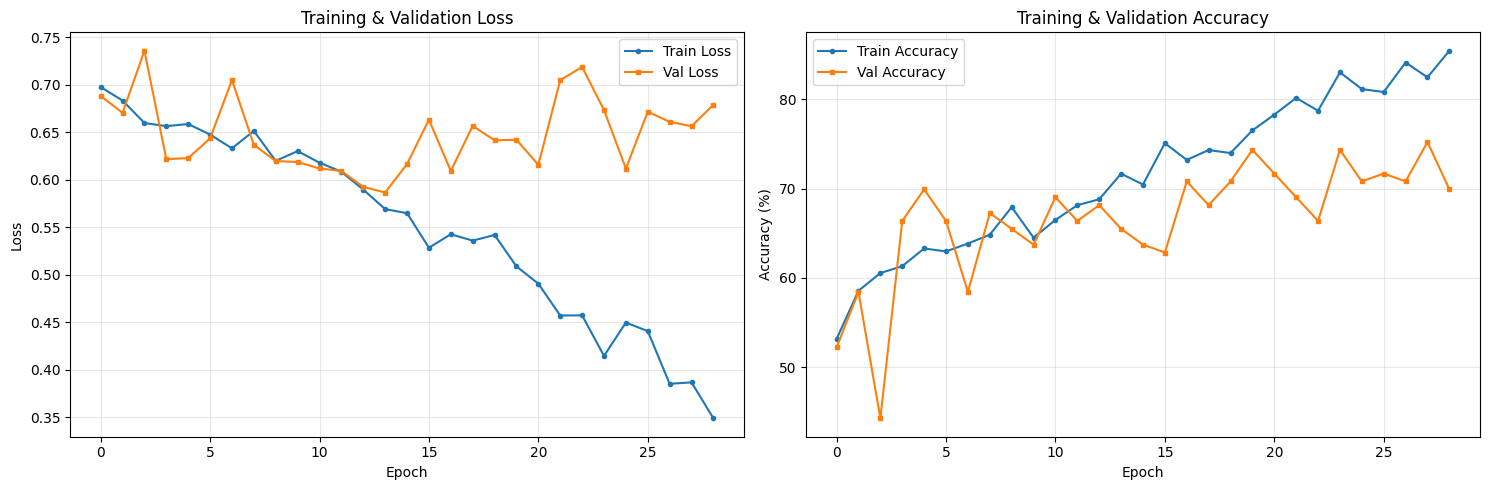

Final Results:
  Train Acc: 85.45%
  Val Acc:   69.91%


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
ax1.plot(history['train_loss'], label='Train Loss', marker='o', markersize=3)
ax1.plot(history['val_loss'], label='Val Loss', marker='s', markersize=3)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(history['train_acc'], label='Train Accuracy', marker='o', markersize=3)
ax2.plot(history['val_acc'], label='Val Accuracy', marker='s', markersize=3)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Training & Validation Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Results:")
print(f"  Train Acc: {history['train_acc'][-1]:.2f}%")
print(f"  Val Acc:   {history['val_acc'][-1]:.2f}%")

## 13. Evaluate on Test Set

Load best model and evaluate on test data.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

# Load best model
print("Loading best model...")
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"  Loaded from epoch {checkpoint['epoch']+1}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val Acc: {checkpoint['val_acc']:.2f}%")
print()

# Evaluate on test set
print("Evaluating on test set...")
test_loss, test_acc, test_preds, test_labels_eval = validate(
    model, test_loader, criterion, DEVICE
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print()

# Detailed metrics
precision, recall, f1, support = precision_recall_fscore_support(
    test_labels_eval, test_preds, average=None, labels=[0, 1]
)

print("Per-Class Metrics:")
print(f"  Negative (0):")
print(f"    Precision: {precision[0]:.4f}")
print(f"    Recall:    {recall[0]:.4f}")
print(f"    F1-Score:  {f1[0]:.4f}")
print(f"    Support:   {support[0]}")
print()
print(f"  Positive (1) - \"رشدي\":")
print(f"    Precision: {precision[1]:.4f}")
print(f"    Recall:    {recall[1]:.4f}")
print(f"    F1-Score:  {f1[1]:.4f}")
print(f"    Support:   {support[1]}")
print()

# Overall metrics
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    test_labels_eval, test_preds, average='macro'
)

print(f"Overall Metrics (Macro Average):")
print(f"  Precision: {macro_precision:.4f}")
print(f"  Recall:    {macro_recall:.4f}")
print(f"  F1-Score:  {macro_f1:.4f}")

Loading best model...
  Loaded from epoch 14
  Val Loss: 0.5866
  Val Acc: 65.49%

Evaluating on test set...


Test Loss: 0.6250
Test Accuracy: 67.54%

Per-Class Metrics:
  Negative (0):
    Precision: 0.8261
    Recall:    0.5672
    F1-Score:  0.6726
    Support:   67

  Positive (1) - "رشدي":
    Precision: 0.5735
    Recall:    0.8298
    F1-Score:  0.6783
    Support:   47

Overall Metrics (Macro Average):
  Precision: 0.6998
  Recall:    0.6985
  F1-Score:  0.6754


## 14. Confusion Matrix

Visualize model predictions.

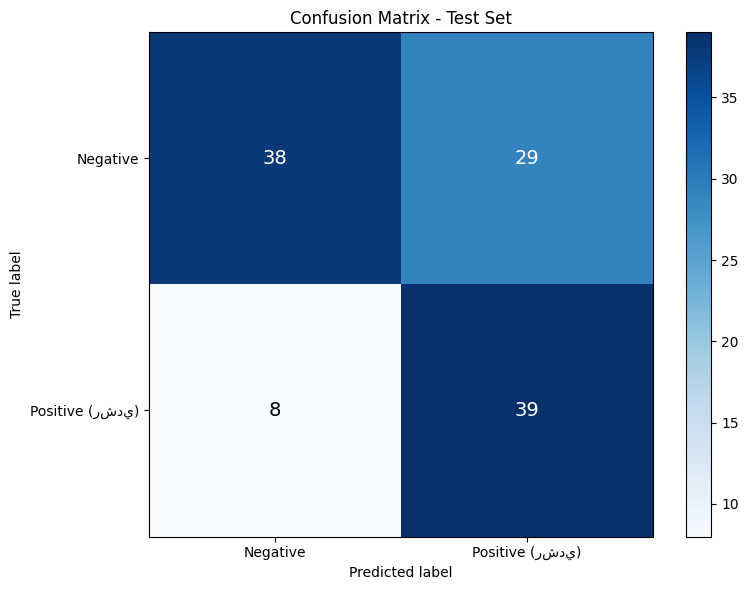


Confusion Matrix:
  True Negatives:  38
  False Positives: 29
  False Negatives: 8
  True Positives:  39


In [ ]:
# Compute confusion matrix
cm = confusion_matrix(test_labels_eval, test_preds)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)

# Labels
class_names = ['Negative', 'Positive (رشدي)']
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=class_names,
       yticklabels=class_names,
       ylabel='True label',
       xlabel='Predicted label',
       title='Confusion Matrix - Test Set')

# Annotate cells
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=14)

plt.tight_layout()
plt.show()

# Print confusion matrix details
print("\nConfusion Matrix:")
print(f"  True Negatives:  {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives:  {cm[1, 1]}")

## 15. Live Inference Functions

Real-time wake word detection on audio files or streams.

In [ ]:
def predict_audio_file(model, audio_path, device, threshold=0.5):
    """
    Predict if audio file contains wake word.
    
    Args:
        model: Trained model
        audio_path: Path to audio file
        device: torch device
        threshold: Confidence threshold (default 0.5)
    
    Returns:
        is_wake_word: Boolean
        confidence: Float confidence score
    """
    model.eval()
    
    try:
        # Load and preprocess audio
        audio = load_and_preprocess_audio(audio_path, SAMPLE_RATE, DURATION)
        
        # Extract features
        mel_spec = audio_to_mel_spectrogram(audio, SAMPLE_RATE, N_MELS)
        
        # Prepare input
        input_tensor = torch.FloatTensor(mel_spec).unsqueeze(0).unsqueeze(0).to(device)
        
        # Inference
        with torch.no_grad():
            if device.type == 'cuda':
                with torch.cuda.amp.autocast():
                    outputs = model(input_tensor)
            else:
                outputs = model(input_tensor)
            
            # Get probabilities
            probs = F.softmax(outputs, dim=1)
            confidence = probs[0, 1].item()  # Probability of positive class
            is_wake_word = confidence >= threshold
        
        return is_wake_word, confidence
    
    except Exception as e:
        print(f"Error processing {audio_path}: {e}")
        return False, 0.0


def predict_audio_array(model, audio_array, sample_rate, device, threshold=0.5):
    """
    Predict if audio array contains wake word.
    Useful for real-time streaming.
    
    Args:
        model: Trained model
        audio_array: Numpy array of audio samples
        sample_rate: Sample rate of audio
        device: torch device
        threshold: Confidence threshold
    
    Returns:
        is_wake_word: Boolean
        confidence: Float confidence score
    """
    model.eval()
    
    try:
        # Resample if needed
        if sample_rate != SAMPLE_RATE:
            audio_array = librosa.resample(audio_array, orig_sr=sample_rate, target_sr=SAMPLE_RATE)
        
        # Ensure correct length
        target_samples = int(DURATION * SAMPLE_RATE)
        if len(audio_array) > target_samples:
            audio_array = audio_array[:target_samples]
        elif len(audio_array) < target_samples:
            audio_array = np.pad(audio_array, (0, target_samples - len(audio_array)))
        
        # Normalize
        if np.max(np.abs(audio_array)) > 0:
            audio_array = audio_array / np.max(np.abs(audio_array))
        
        # Extract features
        mel_spec = audio_to_mel_spectrogram(audio_array, SAMPLE_RATE, N_MELS)
        
        # Prepare input
        input_tensor = torch.FloatTensor(mel_spec).unsqueeze(0).unsqueeze(0).to(device)
        
        # Inference
        with torch.no_grad():
            if device.type == 'cuda':
                with torch.cuda.amp.autocast():
                    outputs = model(input_tensor)
            else:
                outputs = model(input_tensor)
            
            # Get probabilities
            probs = F.softmax(outputs, dim=1)
            confidence = probs[0, 1].item()
            is_wake_word = confidence >= threshold
        
        return is_wake_word, confidence
    
    except Exception as e:
        print(f"Error processing audio array: {e}")
        return False, 0.0


print("Inference functions ready!")
print("  Use predict_audio_file() for audio files")
print("  Use predict_audio_array() for real-time streams")

Inference functions ready!
  Use predict_audio_file() for audio files
  Use predict_audio_array() for real-time streams


## 16. Test Live Inference

Test the model on sample files.

In [ ]:
# Test on random test samples
import random

print("Testing live inference on random test samples...\n")

# Get some test files
positive_files_test = [f for f in Path(POSITIVE_DIR).glob("*.wav")]
negative_files_test = [f for f in Path(NEGATIVE_DIR).glob("*.wav")]

# Test positive samples
print("Positive Samples (should detect wake word):")
print("-" * 60)
for audio_file in random.sample(positive_files_test, min(5, len(positive_files_test))):
    is_wake_word, confidence = predict_audio_file(model, str(audio_file), DEVICE, threshold=0.65)
    status = "-" if is_wake_word else "X"
    print(f"{status} {audio_file.name:<40} | Confidence: {confidence:.4f}")

print()

# Test negative samples
print("ERROR: Negative Samples (should NOT detect wake word):")
print("-" * 60)
for audio_file in random.sample(negative_files_test, min(5, len(negative_files_test))):
    is_wake_word, confidence = predict_audio_file(model, str(audio_file), DEVICE, threshold=0.65)
    status = "X" if not is_wake_word else "-"
    print(f"{status} {audio_file.name:<40} | Confidence: {confidence:.4f}")

print("\n" + "="*60)
print("Tips for deployment:")
print("  - Adjust threshold based on your false positive/negative tolerance")
print("  - Lower threshold = more sensitive (more false positives)")
print("  - Higher threshold = less sensitive (more false negatives)")
print("  - Recommended range: 0.4 - 0.7")
print("="*60)

Testing live inference on random test samples...

Positive Samples (should detect wake word):
------------------------------------------------------------
- REM9eOY3Io0_0001_رشدي_12.26__9815b6c929.wav | Confidence: 0.8506
- 20260301_234554.wav                      | Confidence: 0.8330
X 0s05rYVcaTg_0001_رشدي_5.40__3756db03d2.wav | Confidence: 0.2622
- tT8K49Wz7SA_0001_رشدي_34.00__f94a320cca.wav | Confidence: 0.7158
- 9ciGE12MI4M_0001_رشدي_3.91__e1f7b9ce4b.wav | Confidence: 0.9351

ERROR: Negative Samples (should NOT detect wake word):
------------------------------------------------------------
X brhbaDGlMY0_0001_رشدي_29.50__b4288fb09a.wav | Confidence: 0.5688
X aOspoKTijiw_0001_رشدي_24.08__0297bb074a.wav | Confidence: 0.2998
X 2RVIM_0HYns_0002_رشدي_48.60__bd78faa1d5.wav | Confidence: 0.6494
X 20260302_004156.wav                      | Confidence: 0.0921
X tXu3Jr-Ff1w_0001_رشدي_28.15__3231c84b7f.wav | Confidence: 0.3340

Tips for deployment:
  - Adjust threshold based on your false pos

## 17. Export Model for Production

Save the model for deployment in production environments.

In [ ]:
# Save model configuration and weights
EXPORT_PATH = "wake_word_model.pth"

# Build export data
export_data = {
    'model_architecture': 'WakeWordCNN',
    'model_state_dict': model.state_dict(),
    'config': {
        'sample_rate': SAMPLE_RATE,
        'audio_length': DURATION,
        'n_mels': N_MELS,
        'n_fft': 1024,
        'hop_length': 512,
        'num_classes': 2,
        'class_names': ['negative', 'positive']
    }
}

# Add performance metrics if evaluation has been run
try:
    export_data['performance'] = {
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'precision': float(precision[1]),
        'recall': float(recall[1]),
        'f1_score': float(f1[1])
    }
except NameError:
    print("WARNING: Performance metrics not available. Run evaluation cell first.")
    export_data['performance'] = {}

# Add training info if training has been run
try:
    export_data['training_info'] = {
        'epochs_trained': len(history['train_loss']),
        'best_val_loss': best_val_loss,
        'final_lr': optimizer.param_groups[0]['lr']
    }
except NameError:
    print("WARNING: Training info not available. Run training cell first.")
    export_data['training_info'] = {}

torch.save(export_data, EXPORT_PATH)

print("Model exported successfully!")
print(f"  Saved to: {EXPORT_PATH}")
print()
print("Export includes:")
print("  - Model architecture name")
print("  - Trained weights")
print("  - Audio preprocessing config")
if export_data['performance']:
    print("  - Performance metrics")
if export_data['training_info']:
    print("  - Training metadata")
print()
print("To use in production:")
print("  1. Load the checkpoint: checkpoint = torch.load('wake_word_model.pth')")
print("  2. Create model instance: model = WakeWordCNN(num_classes=2)")
print("  3. Load weights: model.load_state_dict(checkpoint['model_state_dict'])")
print("  4. Set to eval mode: model.eval()")
print("  5. Use predict_audio_file() or predict_audio_array() functions")

Model exported successfully!
  Saved to: wake_word_model.pth

Export includes:
  - Model architecture name
  - Trained weights
  - Audio preprocessing config
  - Performance metrics
  - Training metadata

To use in production:
  1. Load the checkpoint: checkpoint = torch.load('wake_word_model.pth')
  2. Create model instance: model = WakeWordCNN(num_classes=2)
  3. Load weights: model.load_state_dict(checkpoint['model_state_dict'])
  4. Set to eval mode: model.eval()
  5. Use predict_audio_file() or predict_audio_array() functions


## 18. Export for Flutter Mobile Application

Export the model in formats compatible with Flutter and mobile platforms.